In [6]:
import sys
from pathlib import Path

# Current notebook directory
current_dir = Path.cwd()

# Go up one level to project root
project_root = current_dir.parent

# Add project root to Python's search path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project Root:", project_root)

Project Root: c:\Users\NallapureddyRishitha\OneDrive\Desktop\simulation\SW2627-Python-Nexus


In [7]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ---------------------------------------------
# Create output folder
# ---------------------------------------------

Path("../output").mkdir(exist_ok=True)

# ---------------------------------------------
# Import KPI Functions
# ---------------------------------------------

from kpis.kpi_functions import *

# ---------------------------------------------
# Load Dataset
# ---------------------------------------------

df = pd.read_excel(
    "../data/processed/Combined_Data.xlsx",
    sheet_name="Support Tickets"
)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)
print(df.shape)
print(df.head())

# ---------------------------------------------
# Prepare Dataset
# ---------------------------------------------

df = prepare_dataset(df)

# ---------------------------------------------
# Calculate KPIs
# ---------------------------------------------

kpis = calculate_all_kpis(df)

kpi_df = pd.DataFrame(
    list(kpis.items()),
    columns=["KPI", "Value"]
)

print("\nCalculated KPIs\n")
print(kpi_df)

Dataset Loaded Successfully
(476, 8)
   Ticket Id          Student or WP        Program Name Status (Ticket)  \
0       6403  Working Professionals   Fullstack Program          Closed   
1       6415  Working Professionals     Backend Program       Duplicate   
2       6420  Working Professionals   Fullstack Program          Closed   
3       6402                Student   Fullstack Program          Closed   
4       6423  Working Professionals  Fellowship Program          Closed   

  Created Time (Ticket) Ticket Closed Time First Response Time  \
0      14-05-2021 01:09   14-05-2021 19:04    14-05-2021 08:51   
1      14-05-2021 10:12   14-05-2021 11:23                 NaN   
2      14-05-2021 11:46   16-05-2021 00:09    14-05-2021 18:14   
3      14-05-2021 01:08   14-05-2021 19:04    14-05-2021 14:45   
4      14-05-2021 12:17   14-05-2021 20:39    14-05-2021 12:21   

       Project Phase  
0        trial phase  
1        trial phase  
2        trial phase  
3  fullstack-phase-1  


In [8]:
# ---------------------------------------------
# Load KPI Targets
# ---------------------------------------------

with open("../kpis/kpi_validation_targets.json","r") as f:
    targets=json.load(f)

validation=[]

for kpi,value in kpis.items():

    if kpi not in targets:
        continue

    minimum=targets[kpi]["min"]
    maximum=targets[kpi]["max"]

    if pd.isna(value):
        status="NO DATA"

    elif minimum<=value<=maximum:
        status="PASS"

    else:
        status="ALERT"

    validation.append({

        "KPI":kpi,
        "Actual":value,
        "Target Min":minimum,
        "Target Max":maximum,
        "Status":status

    })

validation_df=pd.DataFrame(validation)

print("="*60)
print("Validation Report")
print("="*60)

print(validation_df)

alerts=validation_df[
    validation_df["Status"]=="ALERT"
]

print("\nKPIs Outside Target")

print(alerts)

Validation Report
                                   KPI  Actual  Target Min  Target Max  \
0                        Total Tickets  476.00         100      100000   
1               Closed Ticket Rate (%)   98.32          90         100   
2      Average Resolution Time (Hours)   20.99           0          48   
3  Average First Response Time (Hours)    7.63           0           2   
4          Average Ticket Health Score     NaN           8          10   
5                      Active Programs    3.00           1         100   
6                      Active Students    2.00           1      100000   
7                 Open Ticket Rate (%)    1.68           0          10   

    Status  
0     PASS  
1     PASS  
2     PASS  
3    ALERT  
4  NO DATA  
5     PASS  
6     PASS  
7     PASS  

KPIs Outside Target
                                   KPI  Actual  Target Min  Target Max Status
3  Average First Response Time (Hours)    7.63           0           2  ALERT


Ticket Status Breakdown
Status (Ticket)
Closed                         332
Duplicate                       73
Deleted                         50
Resolved                        12
Waiting for user response        3
Waiting for mentor response      2
Re-opened                        2
Fullstack                        1
Open                             1
Name: count, dtype: int64
Program Breakdown
Program Name
Fullstack Program     242
Backend Program       177
Fellowship Program     57
Name: count, dtype: int64
Project Phase Breakdown
Project Phase
fullstack-phase-2     96
fullstack-phase-1     88
system-issues         77
fellowship-phase-1    46
backend-phase2        45
trial phase           32
fullstack-phase-3     29
backend-phase1        29
fullstack-phase-4     17
backend-phase-3       17
Name: count, dtype: int64


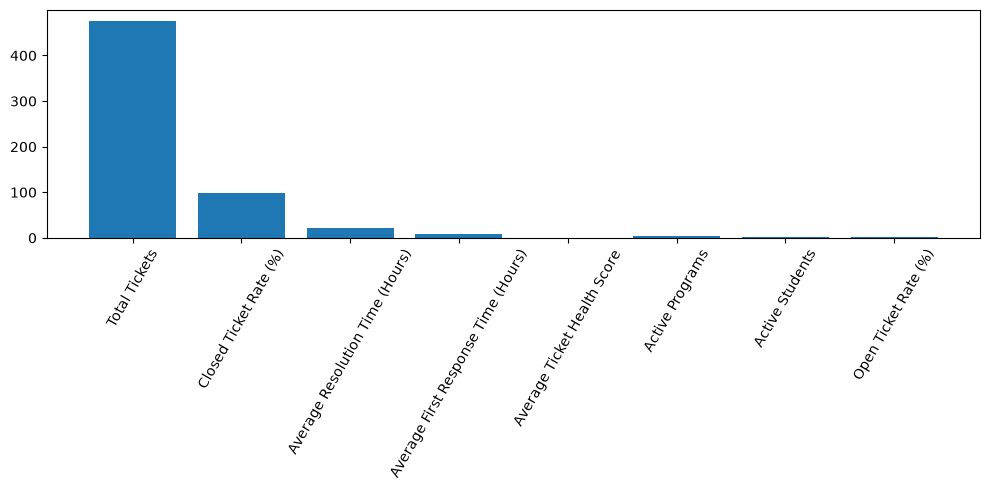

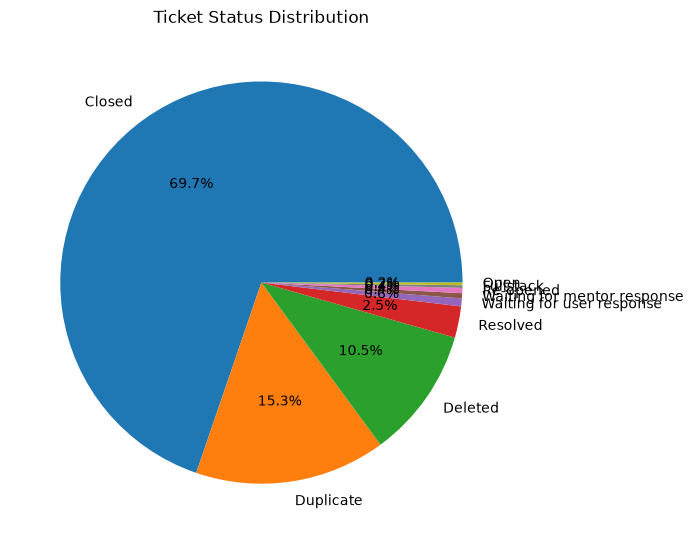

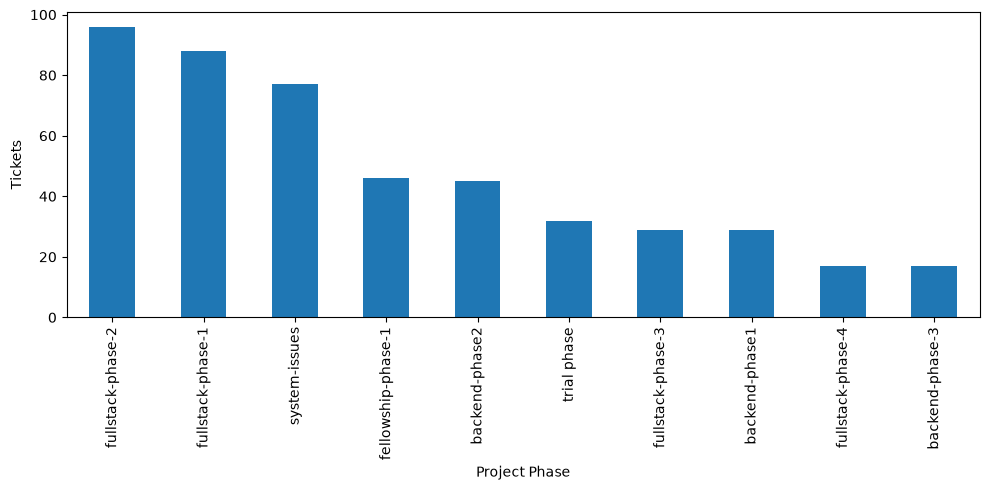

In [9]:
# ---------------------------------------------
# KPI Decomposition
# ---------------------------------------------

status_breakdown=(
    df["Status (Ticket)"]
    .value_counts()
)

program_breakdown=(
    df["Program Name"]
    .value_counts()
)

phase_breakdown=(
    df["Project Phase"]
    .value_counts()
)

print("="*60)
print("Ticket Status Breakdown")
print("="*60)

print(status_breakdown)

print("="*60)
print("Program Breakdown")
print("="*60)

print(program_breakdown)

print("="*60)
print("Project Phase Breakdown")
print("="*60)

print(phase_breakdown)

# ---------------------------------------------
# KPI Chart
# ---------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    kpi_df["KPI"],
    kpi_df["Value"]
)

plt.xticks(rotation=60)

plt.tight_layout()

plt.savefig(
    "../output/KPI_BarChart.png",
    dpi=200
)

plt.show()

# ---------------------------------------------
# Ticket Status Pie Chart
# ---------------------------------------------

plt.figure(figsize=(7,7))

status_breakdown.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Ticket Status Distribution")

plt.tight_layout()

plt.savefig(
    "../output/Ticket_Status.png",
    dpi=200
)

plt.show()

# ---------------------------------------------
# Project Phase Chart
# ---------------------------------------------

plt.figure(figsize=(10,5))

phase_breakdown.plot(
    kind="bar"
)

plt.ylabel("Tickets")

plt.tight_layout()

plt.savefig(
    "../output/Project_Phase.png",
    dpi=200
)

plt.show()

In [10]:
# ---------------------------------------------
# Save Excel Reports
# ---------------------------------------------

kpi_df.to_excel(
    "../output/KPI_Report.xlsx",
    index=False
)

validation_df.to_excel(
    "../output/KPI_Validation.xlsx",
    index=False
)

# ---------------------------------------------
# Summary Report
# ---------------------------------------------

summary=f"""
==================================================

KPI SUMMARY REPORT

==================================================

Total Tickets :
{kpis['Total Tickets']}

Closed Ticket Rate :
{kpis['Closed Ticket Rate (%)']} %

Average Resolution Time :
{kpis['Average Resolution Time (Hours)']} Hours

Average First Response Time :
{kpis['Average First Response Time (Hours)']} Hours

Average Ticket Health Score :
{kpis['Average Ticket Health Score']}

Active Programs :
{kpis['Active Programs']}

Active Students :
{kpis['Active Students']}

Open Ticket Rate :
{kpis['Open Ticket Rate (%)']} %

==================================================

Validation Summary

==================================================

{validation_df.to_string(index=False)}

==================================================

Status Breakdown

==================================================

{status_breakdown.to_string()}

==================================================

Program Breakdown

==================================================

{program_breakdown.to_string()}

==================================================

Project Phase Breakdown

==================================================

{phase_breakdown.to_string()}

"""

with open(
    "../output/KPI_Summary.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(summary)

print("="*60)
print("Files Generated Successfully")
print("="*60)

print("../output/KPI_Report.xlsx")
print("../output/KPI_Validation.xlsx")
print("../output/KPI_Summary.txt")
print("../output/KPI_BarChart.png")
print("../output/Ticket_Status.png")
print("../output/Project_Phase.png")

Files Generated Successfully
../output/KPI_Report.xlsx
../output/KPI_Validation.xlsx
../output/KPI_Summary.txt
../output/KPI_BarChart.png
../output/Ticket_Status.png
../output/Project_Phase.png
